In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_excel("Data_Model_IoTMLCQ_2024.xlsx")

print(df.shape)
df.head()

(4383, 28)


,Datetime,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,...,day,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status
0,2024-01-01 00:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable
1,2024-01-01 01:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable
2,2024-01-01 02:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable
3,2024-01-01 03:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable
4,2024-01-01 04:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable


In [3]:
print(df.isnull().sum())

Datetime                      0
Month                         0
Average Fish Weight (g)       0
Survival Rate (%)             0
Disease Occurrence (Cases)    0
Temperature (°C)              0
Dissolved Oxygen (mg/L)       0
pH                            0
Turbidity (NTU)               0
Month_Num                     0
month_x                       0
Oxygenation Interventions     0
Corrective Interventions      0
Average Temperature (°C)      0
High Temperature (°C)         0
Low Temperature (°C)          0
Precipitation (inches)        0
month_y                       0
day                           0
hour                          0
oxigeno_scaled                0
ph                            0
turbidez                      0
Oxygenation Automatic         0
Corrective Measures           0
Thermal Risk Index            0
Low Oxygen Alert              0
Health Status                 0
dtype: int64


In [4]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df["Datetime_ts"] = (
    df["Datetime"].astype("int64") // 10**9
)

df.drop(columns=["Datetime"], inplace=True)

In [5]:
df["Health Status"] = df["Health Status"].map({
    "Stable": 0,
    "At Risk": 1
})

In [6]:
print(df["Health Status"].value_counts())

Health Status
0    3678
1     705
Name: count, dtype: int64


In [7]:
feature_cols = [
    'Temperature (°C)',
    'Thermal Risk Index',
    'Average Fish Weight (g)',
    'Survival Rate (%)',
    'Dissolved Oxygen (mg/L)',
    'pH',
    'Datetime_ts',
    'month_y',
    'month_x'
]

X = df[feature_cols]

y = df['Health Status']

In [8]:
print(X.shape)
print(y.shape)

(4383, 9)
(4383,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print(X.dtypes)

Temperature (°C)           float64
Thermal Risk Index             str
Average Fish Weight (g)    float64
Survival Rate (%)          float64
Dissolved Oxygen (mg/L)    float64
pH                         float64
Datetime_ts                  int64
month_y                    float64
month_x                    float64
dtype: object


In [11]:
print(df["Thermal Risk Index"].unique())

<StringArray>
['Normal', 'High']
Length: 2, dtype: str


In [12]:
df["Thermal Risk Index"] = df["Thermal Risk Index"].map({
    "Normal": 0,
    "High": 1
})

In [13]:
print(df["Thermal Risk Index"].dtype)

int64


In [48]:
feature_cols = [
    'Temperature (°C)',
    'Dissolved Oxygen (mg/L)',
    'pH',
    'Datetime_ts',
    'month_y',
    'month_x',
    'Month_Num',
    'Turbidity (NTU)'
    
]

X = df[feature_cols]
y = df['Health Status']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [50]:
y_pred = rf.predict(X_test)

In [51]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.9988597491448119

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       736
           1       1.00      0.99      1.00       141

    accuracy                           1.00       877
   macro avg       1.00      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



In [52]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
0         Temperature (°C)    0.289894
1  Dissolved Oxygen (mg/L)    0.244217
2                       pH    0.143816
7          Turbidity (NTU)    0.085619
5                  month_x    0.061309
4                  month_y    0.060477
6                Month_Num    0.057764
3              Datetime_ts    0.056904


In [53]:
print(df.columns.tolist())

['Month', 'Average Fish Weight (g)', 'Survival Rate (%)', 'Disease Occurrence (Cases)', 'Temperature (°C)', 'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)', 'Month_Num', 'month_x', 'Oxygenation Interventions', 'Corrective Interventions', 'Average Temperature (°C)', 'High Temperature (°C)', 'Low Temperature (°C)', 'Precipitation (inches)', 'month_y', 'day', 'hour', 'oxigeno_scaled', 'ph', 'turbidez', 'Oxygenation Automatic', 'Corrective Measures', 'Thermal Risk Index', 'Low Oxygen Alert', 'Health Status', 'Datetime_ts']


In [54]:
for col in [
    'Thermal Risk Index',
    'Low Oxygen Alert',
    'Oxygenation Automatic',
    'Corrective Measures'
]:
    print("\n", col)
    print(pd.crosstab(df[col], df['Health Status']))


 Thermal Risk Index
Health Status          0    1
Thermal Risk Index           
0                   3678    0
1                      0  705

 Low Oxygen Alert
Health Status        0    1
Low Oxygen Alert           
Safe              3678  705

 Oxygenation Automatic
Health Status             0    1
Oxygenation Automatic           
No                     1838  353
Yes                    1840  352

 Corrective Measures
Health Status           0    1
Corrective Measures           
No                   3434  705
Yes                   244    0


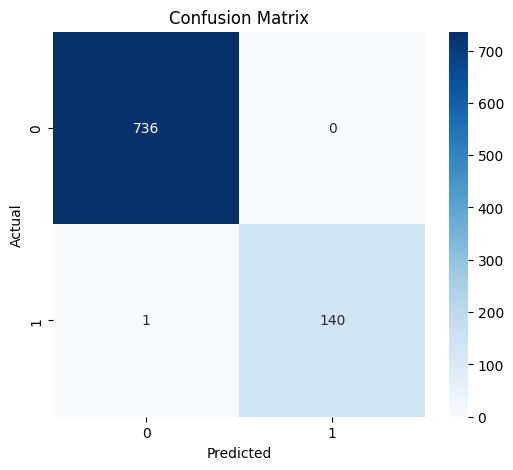

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
train_acc = rf.score(
    X_train,
    y_train
)

test_acc = rf.score(
    X_test,
    y_test
)

print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)

Train Accuracy : 1.0
Test Accuracy  : 0.9988597491448119


In [57]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:")
print(scores)

print("\nMean CV:")
print(scores.mean())

CV Scores:
[0.99885975 0.97035348 1.         1.         0.96575342]

Mean CV:
0.9869933303134909


In [58]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved")

Feature importance saved


In [59]:
import joblib

joblib.dump(
    rf,
    "rf.pkl"
)

print("Model saved")

Model saved


In [60]:
model_info = {
    "features": feature_cols,
    "target_mapping": {
        "Stable": 0,
        "At Risk": 1
    }
}

joblib.dump(
    model_info,
    "rf_metadata.pkl"
)

print("Metadata saved")

Metadata saved


In [61]:
loaded_model = joblib.load(
    "rf.pkl"
)

sample = X.iloc[[0]]

prediction = loaded_model.predict(
    sample
)

print(prediction)

[0]


In [62]:
sample = X_test.iloc[[0]]

print("Input:")
print(sample)

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]

print("\nActual:")
print(y_test.iloc[0])

print("\nPrediction:")
print("At Risk" if pred == 1 else "Stable")

print("\nProbability:")
print(f"Stable : {proba[0]*100:.2f}%")
print(f"At Risk: {proba[1]*100:.2f}%")

print("\nConfidence:")
print(f"{max(proba)*100:.2f}%")

Input:
      Temperature (°C)  Dissolved Oxygen (mg/L)    pH  Datetime_ts  month_y  \
3865             27.45                     7.72  7.88      1717981      6.0   

      month_x  Month_Num  Turbidity (NTU)  
3865      6.0        6.0             3.71  

Actual:
0

Prediction:
Stable

Probability:
Stable : 99.99%
At Risk: 0.01%

Confidence:
99.99%


In [63]:
at_risk_samples = X_test[
    y_test.loc[X_test.index] == 1
]

sample = at_risk_samples.iloc[[0]]

print(sample)

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]

print("\nPrediction:")
print("At Risk" if pred == 1 else "Stable")

print("\nProbability:")
print(proba)

print("\nConfidence:")
print(f"{max(proba)*100:.2f}%")

      Temperature (°C)  Dissolved Oxygen (mg/L)    pH  Datetime_ts  month_y  \
1716             28.35                     7.89  7.97      1710244      3.0   

      month_x  Month_Num  Turbidity (NTU)  
1716      3.0        3.0             2.79  

Prediction:
At Risk

Probability:
[0. 1.]

Confidence:
100.00%


In [64]:
stable_samples = X_test[
    y_test.loc[X_test.index] == 0
]

sample = stable_samples.iloc[[0]]

print(sample)

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]

print("\nPrediction:")
print("At Risk" if pred == 1 else "Stable")

print("\nProbability:")
print(proba)

print("\nConfidence:")
print(f"{max(proba)*100:.2f}%")

      Temperature (°C)  Dissolved Oxygen (mg/L)    pH  Datetime_ts  month_y  \
3865             27.45                     7.72  7.88      1717981      6.0   

      month_x  Month_Num  Turbidity (NTU)  
3865      6.0        6.0             3.71  

Prediction:
Stable

Probability:
[9.99908429e-01 9.15706451e-05]

Confidence:
99.99%


In [65]:
probas = loaded_model.predict_proba(X_test)

confidence = probas.max(axis=1)

idx = confidence.argmax()

print("Index:", idx)

sample = X_test.iloc[[idx]]

print(sample)

pred = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]

print("\nPrediction:")
print("At Risk" if pred == 1 else "Stable")

print("\nProbability:")
print(proba)

print("\nConfidence:")
print(f"{max(proba)*100:.2f}%")

Index: 1
      Temperature (°C)  Dissolved Oxygen (mg/L)    pH  Datetime_ts  month_y  \
1716             28.35                     7.89  7.97      1710244      3.0   

      month_x  Month_Num  Turbidity (NTU)  
1716      3.0        3.0             2.79  

Prediction:
At Risk

Probability:
[0. 1.]

Confidence:
100.00%


In [66]:
print(
    pd.crosstab(
        df["Health Status"],
        pd.qcut(
            df["Survival Rate (%)"],
            5
        )
    )
)

Survival Rate (%)  (92.84899999999999, 92.93]  (92.93, 92.96]  (92.96, 93.05]  \
Health Status                                                                   
0                                        1503             720             656   
1                                           0               0               0   

Survival Rate (%)  (93.05, 95.27]  (95.27, 96.3]  
Health Status                                     
0                             796              3  
1                              20            685  


In [67]:
print(
    pd.crosstab(
        df["Health Status"],
        pd.qcut(
            df["Average Fish Weight (g)"],
            5
        )
    )
)

Average Fish Weight (g)  (262.04900000000004, 262.82]  (262.82, 275.82]  \
Health Status                                                             
0                                                1506               713   
1                                                   0                 0   

Average Fish Weight (g)  (275.82, 276.79]  (276.79, 278.1]  (278.1, 286.5]  
Health Status                                                               
0                                     696              718              45  
1                                       0                0             705  


In [73]:
new_data = pd.DataFrame([{
    "Temperature (°C)": 34.0,
    "Dissolved Oxygen (mg/L)": 1.5,
    "pH": 4.5,
    "Datetime_ts": 1719800000,
    "month_y": 7,
    "month_x": 7,
    "Month_Num": 7,
    "Turbidity (NTU)": 15.0
}])

pred = loaded_model.predict(new_data)
proba = loaded_model.predict_proba(new_data)

print("Prediction:", "At Risk" if pred[0] == 1 else "Stable")
print("Stable :", f"{proba[0][0]*100:.2f}%")
print("At Risk:", f"{proba[0][1]*100:.2f}%")
print("Confidence:", f"{max(proba[0])*100:.2f}%")

Prediction: Stable
Stable : 61.97%
At Risk: 38.03%
Confidence: 61.97%
